# 6-qubit block reduction

In this code we test the idea of "replacement" of the the 6-qubit block (full block)

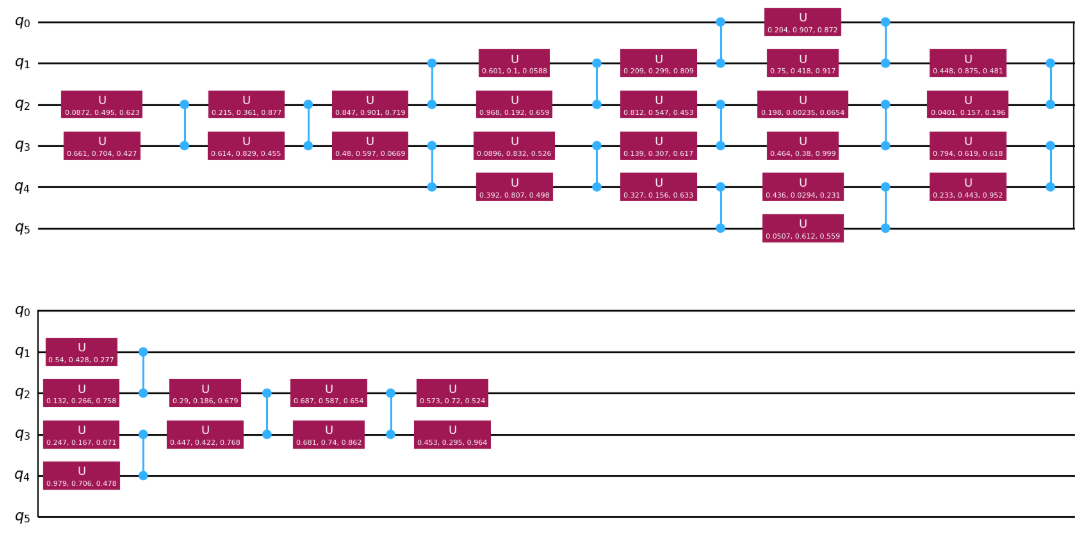

with the 6-qubit block (reduced block)

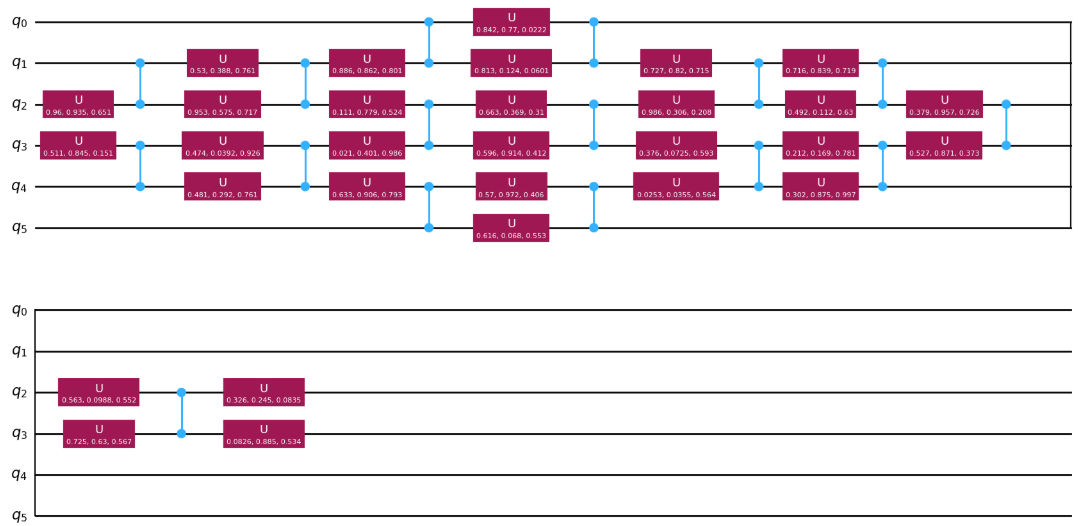

Replacement means that we find the reduced block that has approximately the same operator as the full block.

To find the reduced block we use optimization procedure, where we optimize U3-gates agles of the reduced block to fit the initial full block.

We used standard deviation of each element of a matrix of the reduced block from the elements of the initial full block matrix as a measure of precision.

## Some conclusions
1) Typical value of standard deviation of each elemet in the 64 x 64 matrix between full and reduced block is about 0.001. Note that the maximum value of any element is below 1.
2) The optimization goes better (higher precision is obtained) if the angles of the U-gates in the initial full block are smaller.

In [9]:
import qiskit
from qiskit import QuantumRegister as Q_R
from qiskit import ClassicalRegister as C_R
from qiskit_aer import AerSimulator
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit.visualization import array_to_latex

from IPython.display import display

import numpy as np
import random
import copy
import time

# SciPy minimizer routine
from scipy.optimize import minimize

PI = np.pi

### Define all the functions for creating and optimizing the blocks

In [14]:
def block_6_circ(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)
    q_2.cz(2,3)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.u(par[39], par[40], par[41], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[42], par[43], par[44], 0)
    q_2.u(par[45], par[46], par[47], 1)
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.u(par[54], par[55], par[56], 4)
    q_2.u(par[57], par[58], par[59], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[72], par[73], par[74], 1)
    q_2.u(par[75], par[76], par[77], 2)
    q_2.u(par[78], par[79], par[80], 3)
    q_2.u(par[81], par[82], par[83], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    q_2.cz(2,3)
    q_2.u(par[90], par[91], par[92], 2)
    q_2.u(par[93], par[94], par[95], 3)
    q_2.cz(2,3)
    q_2.u(par[96], par[97], par[98], 2)
    q_2.u(par[99], par[100], par[101], 3)
    
    return q_2

def block_6(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)
    q_2.cz(2,3)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.cz(2,3)
    q_2.u(par[12], par[13], par[14], 2)
    q_2.u(par[15], par[16], par[17], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[30], par[31], par[32], 1)
    q_2.u(par[33], par[34], par[35], 2)
    q_2.u(par[36], par[37], par[38], 3)
    q_2.u(par[39], par[40], par[41], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[42], par[43], par[44], 0)
    q_2.u(par[45], par[46], par[47], 1)
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.u(par[54], par[55], par[56], 4)
    q_2.u(par[57], par[58], par[59], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[72], par[73], par[74], 1)
    q_2.u(par[75], par[76], par[77], 2)
    q_2.u(par[78], par[79], par[80], 3)
    q_2.u(par[81], par[82], par[83], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    q_2.cz(2,3)
    q_2.u(par[90], par[91], par[92], 2)
    q_2.u(par[93], par[94], par[95], 3)
    q_2.cz(2,3)
    q_2.u(par[96], par[97], par[98], 2)
    q_2.u(par[99], par[100], par[101], 3)
    
    op = Operator(q_2)
    return op

def reduced_block_6_circ(par):

    q_2 = qiskit.QuantumCircuit(6)
    
    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.u(par[12], par[13], par[14], 3)
    q_2.u(par[15], par[16], par[17], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[30], par[31], par[32], 0)
    q_2.u(par[33], par[34], par[35], 1)
    q_2.u(par[36], par[37], par[38], 2)
    q_2.u(par[39], par[40], par[41], 3)
    q_2.u(par[42], par[43], par[44], 4)
    q_2.u(par[45], par[46], par[47], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    q_2.cz(2,3)
    q_2.u(par[78], par[79], par[80], 2)
    q_2.u(par[81], par[82], par[83], 3)
    q_2.cz(2,3)
    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    
    return q_2


def reduced_block_6(par):
    q_2 = qiskit.QuantumCircuit(6)

    q_2.u(par[0], par[1], par[2], 2)
    q_2.u(par[3], par[4], par[5], 3)

    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[6], par[7], par[8], 1)
    q_2.u(par[9], par[10], par[11], 2)
    q_2.u(par[12], par[13], par[14], 3)
    q_2.u(par[15], par[16], par[17], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[18], par[19], par[20], 1)
    q_2.u(par[21], par[22], par[23], 2)
    q_2.u(par[24], par[25], par[26], 3)
    q_2.u(par[27], par[28], par[29], 4)


    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    q_2.u(par[30], par[31], par[32], 0)
    q_2.u(par[33], par[34], par[35], 1)
    q_2.u(par[36], par[37], par[38], 2)
    q_2.u(par[39], par[40], par[41], 3)
    q_2.u(par[42], par[43], par[44], 4)
    q_2.u(par[45], par[46], par[47], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    q_2.u(par[60], par[61], par[62], 1)
    q_2.u(par[63], par[64], par[65], 2)
    q_2.u(par[66], par[67], par[68], 3)
    q_2.u(par[69], par[70], par[71], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    q_2.cz(2,3)
    q_2.u(par[78], par[79], par[80], 2)
    q_2.u(par[81], par[82], par[83], 3)
    q_2.cz(2,3)
    q_2.u(par[84], par[85], par[86], 2)
    q_2.u(par[87], par[88], par[89], 3)
    
    op = Operator(q_2)
    return op


def double_q_diff(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el

cost_history_dict = []
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

def estim_func_6(params, init_circ):
    #init_circ = block_4_1(params_init)
    test_circ = reduced_block_6(params)
    est = double_q_diff(init_circ, test_circ)
    cost_history_dict["iters"] += 1
    cost_history_dict["prev_vector"] = params
    cost_history_dict["cost_history"].append(est)
    return est
    
def find_alt_params_6(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(90) * 2 * PI
        cost_history_dict = {
            "prev_vector": None,
            "iters": 0,
            "cost_history": [],
        }
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

### Show the initial full block and reduced block obtained with the functions defined above

In [15]:
random_array = np.random.rand(102)
qc = block_6_circ(random_array)
#qc.draw('mpl')

In [16]:
random_array = np.random.rand(90)
qc = reduced_block_6_circ(random_array)
#qc.draw('mpl')

### Test how optimization works and how well the initial full block can be replaced with the reduced block

In [17]:
cost_history_dict = {
    "prev_vector": None,
    "iters": 0,
    "cost_history": [],
}

start_time = time.time()
new_params = []
block_devs = []
prec = 0.005
n_tries = 2
for i in range(1):
    params_init = np.random.rand(102)* 2 * PI
    res_min = find_alt_params_6(params_init, prec, n_tries)
    new_params.append(res_min.x)
    block_devs.append(res_min.fun)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")
#print(new_params)

Elapsed time: 33.110254526138306 seconds


In [18]:
# Check the deviation of the reduced block from the initial full block
# deviation is just standard deviation of elements in the matrix describing the reduced block from the elements in the full block matrix
# see function double_q_diff(mat_1, mat_2): for more details
block_devs #this is std of each element in the matrix (64 x 64)

[0.0011418939455483013]

# Here are also trying to replace a 6-qubit block with a shorter one. However, here we assume that the input state to the block is fixed and this is |0>^n state

We use a different 6-qubit block here.

We replace block:
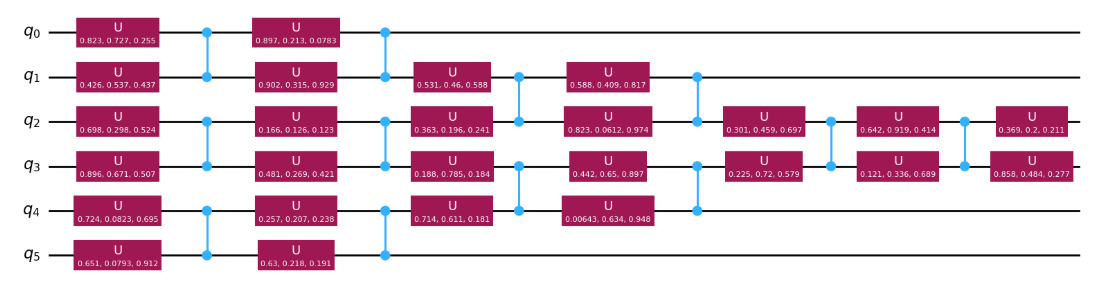

with the block:

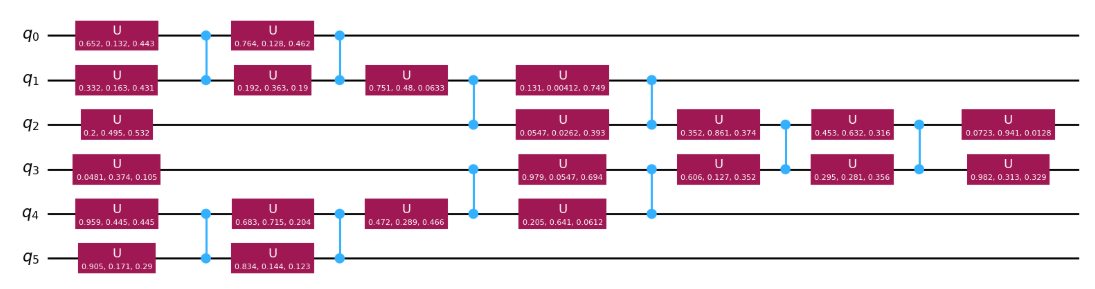

We optimize only the first row of the matrix, since the initial state is |0>^n. So, the rest of the matrix does not matter.
So, the loss function here is different comparing to the previous case. 

In previous cases I cannot use such an approach, since the state to which the matrix is applied is not |0>^n.


## Some conclusions

If one takes in the initial qubit state into account, one can get better aproximation of the full block with a reduced block. I see that this allows to increase precision twice.

### Define all the functions for creating and optimizing the blocks

In [19]:
def block_6_2_circ(par):
    q_2 = qiskit.QuantumCircuit(6)
    
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
  
    
    return q_2

def block_6_2(par):
    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 2)
    q_2.u(par[9], par[10], par[11], 3)
    q_2.u(par[12], par[13], par[14], 4)
    q_2.u(par[15], par[16], par[17], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)

    

    q_2.u(par[18], par[19], par[20], 0)
    q_2.u(par[21], par[22], par[23], 1)
    q_2.u(par[24], par[25], par[26], 2)
    q_2.u(par[27], par[28], par[29], 3)
    q_2.u(par[30], par[31], par[32], 4)
    q_2.u(par[33], par[34], par[35], 5)
    q_2.cz(0,1)
    q_2.cz(2,3)
    q_2.cz(4,5)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)

    
    q_2.u(par[48], par[49], par[50], 1)
    q_2.u(par[51], par[52], par[53], 2)
    q_2.u(par[54], par[55], par[56], 3)
    q_2.u(par[57], par[58], par[59], 4)
    q_2.cz(1,2)
    q_2.cz(3,4)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    q_2.cz(2,3)
    
    q_2.u(par[66], par[67], par[68], 2)
    q_2.u(par[69], par[70], par[71], 3)
    q_2.cz(2,3)
    
    q_2.u(par[72], par[73], par[74], 2)
    q_2.u(par[75], par[76], par[77], 3)
    op = Operator(q_2)
    return op

def reduced_block_6_2_circ(par):

    q_2 = qiskit.QuantumCircuit(6)
    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
        
    return q_2


def reduced_block_6_2(par):
    q_2 = qiskit.QuantumCircuit(6)

    q_2.u(par[0], par[1], par[2], 0)
    q_2.u(par[3], par[4], par[5], 1)
    q_2.u(par[6], par[7], par[8], 4)
    q_2.u(par[9], par[10], par[11], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[12], par[13], par[14], 0)
    q_2.u(par[15], par[16], par[17], 1)
    q_2.u(par[18], par[19], par[20], 4)
    q_2.u(par[21], par[22], par[23], 5)
    q_2.cz(0, 1)
    q_2.cz(4, 5)
    
    q_2.u(par[24], par[25], par[26], 1)
    q_2.u(par[27], par[28], par[29], 2)
    q_2.u(par[30], par[31], par[32], 3)
    q_2.u(par[33], par[34], par[35], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[36], par[37], par[38], 1)
    q_2.u(par[39], par[40], par[41], 2)
    q_2.u(par[42], par[43], par[44], 3)
    q_2.u(par[45], par[46], par[47], 4)
    q_2.cz(1, 2)
    q_2.cz(3, 4)
    
    q_2.u(par[48], par[49], par[50], 2)
    q_2.u(par[51], par[52], par[53], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[54], par[55], par[56], 2)
    q_2.u(par[57], par[58], par[59], 3)
    q_2.cz(2, 3)
    
    q_2.u(par[60], par[61], par[62], 2)
    q_2.u(par[63], par[64], par[65], 3)
    
    op = Operator(q_2)
    return op


def double_q_diff_full(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    return np.linalg.norm(mm)/numb_el


def double_q_diff_partial(mat_1, mat_2):
    mm = mat_1 - mat_2
    numb_el = mm.data.size
    #print(numb_el)
    diff = 0 
    for i in range(0,64):
        for j in range(0,1):
            diff = diff + abs(mm.data[i][j]) * abs(mm.data[i][j])
    diff = np.sqrt(diff/64)
    return diff

def estim_func_6_2_full(params, init_circ):
    test_circ = reduced_block_6_2(params)
    est = double_q_diff_full(init_circ, test_circ)
    return est

def estim_func_6_2_partial(params, init_circ):
    test_circ = reduced_block_6_2(params)
    est = double_q_diff_partial(init_circ, test_circ)
    return est
    
def find_alt_params_6_full(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6_2(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_2_full,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

def find_alt_params_6_partial(param_init, prec, n_tries):
    min_dev = 10000
    init_circ = block_6_2(param_init)
    for i in range(n_tries):
        param_0 = np.random.rand(78) * 2 * PI
        #param_0 = param_init[12:60]
        res = minimize(
                    estim_func_6_2_partial,
                    param_0,
                    args = (init_circ),
                    method = 'COBYLA', 
                    options = {"maxiter":  5000} 
                )
        #print(res.fun)
        #print(res.x)
        if res.fun < min_dev:
            min_dev_par = res
            min_dev = res.fun
        if res.fun < prec:
            break
    
    return min_dev_par

### Show the initial full block and reduced block obtained with the functions defined above

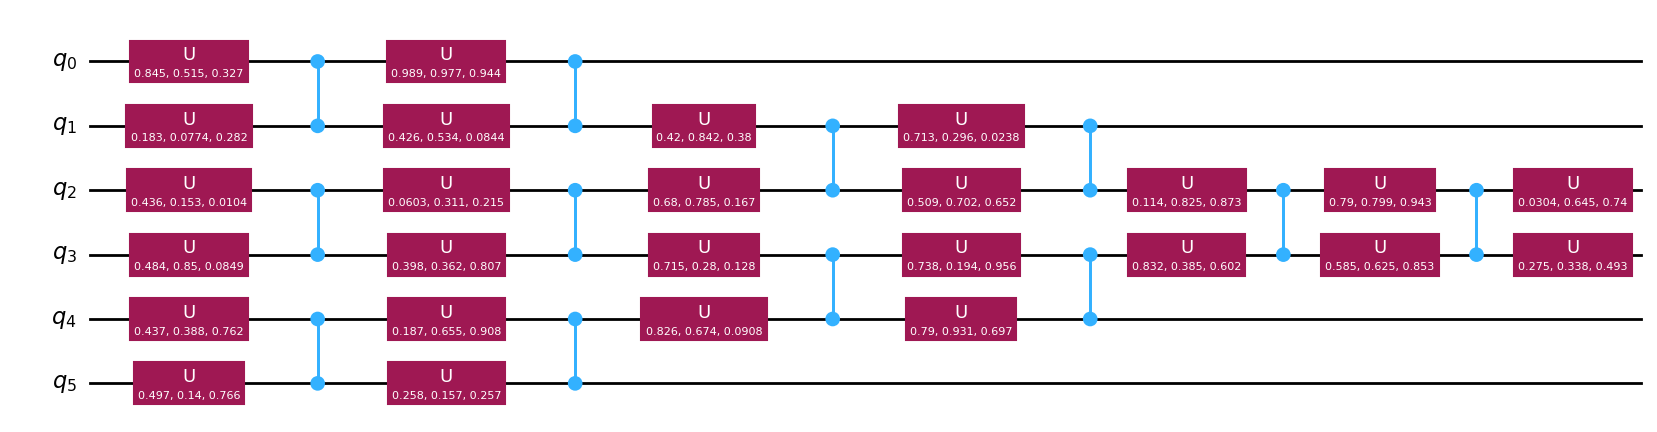

In [20]:
random_array = np.random.rand(78)
qc = block_6_2_circ(random_array)
qc.draw('mpl')

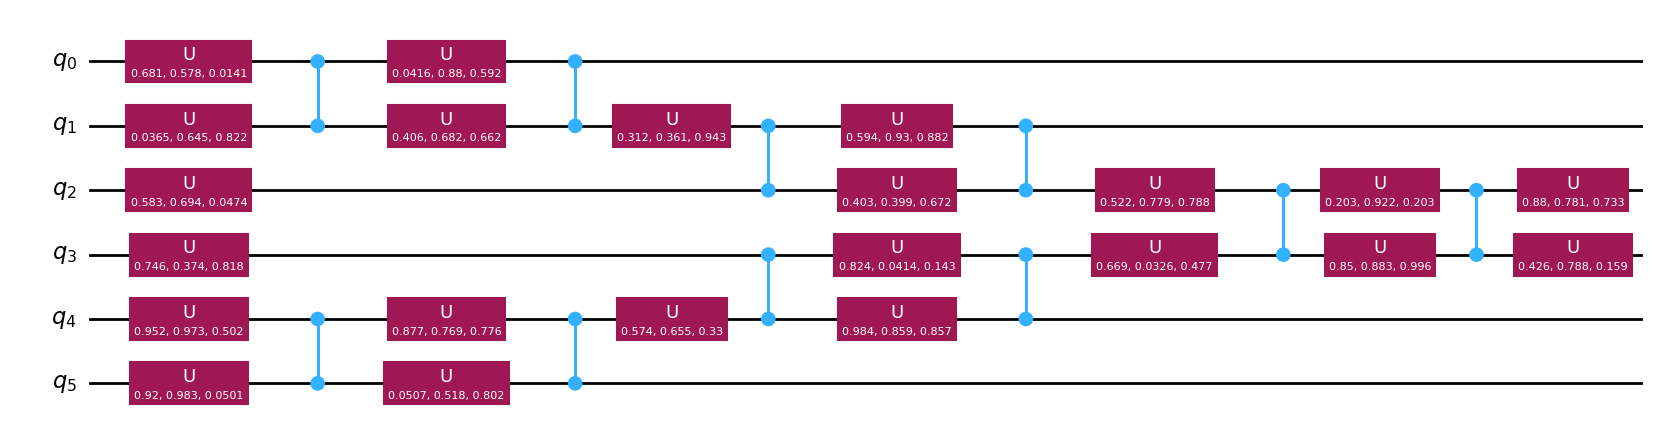

In [21]:
random_array = np.random.rand(66)
qc = reduced_block_6_2_circ(random_array)
qc.draw('mpl')

### Test how optimization works and how well the initial full block can be replaced with the reduced block

In [25]:
# Here the code compares two approaches. 
# The first is when we do not use any information of the qubits initial states
# The second one assumes the |0>^n initial state
# We create intial full block
# We get the reduced block by two above mentioned method
# We perfrom quantum simulations for all three blocks (full and two reduced ones)
# We compare counts for reduced blocks and initial block.
# Eventually, we caculate average difference between the counts for all final states
# We output number of final states that coincide and avaerage difference in counts.
# First we show the case where the initial state is not accounted for
# Second we show the case where |0>^n state is assumed
start_time = time.time()
new_params_full = []
block_devs_full = []
new_params_partial = []
block_devs_partial = []
prec = 0.005
n_tries = 2
for i in range(1):
    params_init = np.random.rand(78)* 2 * PI #define full block parameters
    res_min_full = find_alt_params_6_full(params_init, prec, n_tries) #get reduced block parameters without accounting of the initial state
    res_min_partial = find_alt_params_6_partial(params_init, prec, n_tries) #get reduced block parameters with accounting of the initial state
    
    new_params_full.append(res_min_full.x)
    block_devs_full.append(res_min_full.fun)
    new_params_partial.append(res_min_partial.x)
    block_devs_partial.append(res_min_partial.fun)

    #create circuits for initial full and two reduced blocks
    qc_init = block_6_2_circ(params_init)
    qc_init.measure_all()
    qc_red_full = reduced_block_6_2_circ(new_params_full[i])
    qc_red_full.measure_all()
    qc_red_partial = reduced_block_6_2_circ(new_params_partial[i])
    qc_red_partial.measure_all()

    #simulate all three circuits
    qc_merged_t = transpile(qc_init, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_init = result.get_counts(qc_merged_t)
    
    qc_merged_t = transpile(qc_red_full, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_red_full = result.get_counts(qc_merged_t)
    
    qc_merged_t = transpile(qc_red_partial, simulator)
    result = simulator.run(qc_merged_t,shots = 1000).result()
    counts_red_partial = result.get_counts(qc_merged_t)
    
    #calculate the difference between counts in initial full cisuit and reduced circuits
    diff_full = 0
    n = 0
    for k in counts_init.keys() & counts_red_full.keys():
        diff_full = diff_full + (counts_init[k] - counts_red_full[k]) * (counts_init[k] - counts_red_full[k])
        n = n + 1
    diff_full = np.sqrt(diff_full/n)
    
    print(n)
    print(diff_full)
    
    diff_partial = 0
    n = 0
    for k in counts_init.keys() & counts_red_partial.keys():
        diff_partial = diff_partial + (counts_init[k] - counts_red_partial[k]) * (counts_init[k] - counts_red_partial[k])
        n = n + 1
    diff_partial = np.sqrt(diff_partial/n)
    
    print(n)
    print(diff_partial)
    
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Elapsed time: {elapsed_time} seconds")

23
43.97627819038647
26
8.204126541423669
Elapsed time: 74.5317394733429 seconds
